In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from classes import Dense, Model, ReLU
from functions import *

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

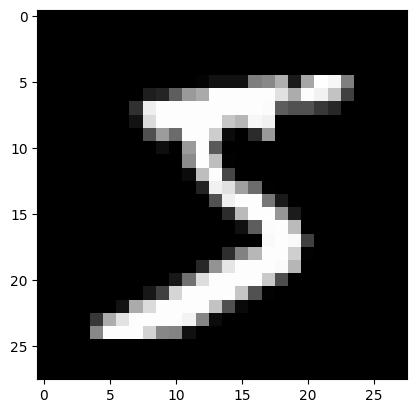

In [ ]:
plt.imshow(x_train[0], cmap='gray') / 255 

In [4]:
# Preprocessing
train = x_train.reshape(-1, 784) / 255 
test = x_test.reshape(-1, 784) / 255


def ohe(labels):
    temp = np.zeros((len(labels), 10))
    for i,l in enumerate(labels):
        temp[i][l] = 1
    return temp
train_labels = ohe(y_train)
test_labels = ohe(y_test)

In [25]:
model = Model([
    Dense((784, 64)), ReLU(),  Dense((64, 64)), ReLU(), Dense((64, 10))
])
hist = model.train(train, train_labels, lr=0.001, batch_size=32, loss=mse, metric=acc_score, epochs=50, val_data=(test, test_labels))

epoch 0: train_loss: 0.04507186137735092, train_acc: 0.1965, test_error: 0.04184880023917382, test_acc: 0.3528
epoch 1: train_loss: 0.03990069465548486, train_acc: 0.44588333333333335, test_error: 0.037736830444011486, test_acc: 0.5173
epoch 2: train_loss: 0.03595355824791247, train_acc: 0.5556666666666666, test_error: 0.03397146399260067, test_acc: 0.5944
epoch 3: train_loss: 0.03258909313596659, train_acc: 0.61825, test_error: 0.03101551302905233, test_acc: 0.6488
epoch 4: train_loss: 0.03004945519338556, train_acc: 0.6657666666666666, test_error: 0.02878977551829322, test_acc: 0.7013
epoch 5: train_loss: 0.028058350161392163, train_acc: 0.7060166666666666, test_error: 0.02696047886767586, test_acc: 0.7334
epoch 6: train_loss: 0.026417535853539956, train_acc: 0.7297, test_error: 0.025442053611544, test_acc: 0.7547
epoch 7: train_loss: 0.02505365957678869, train_acc: 0.7474833333333334, test_error: 0.024173006233071337, test_acc: 0.7707
epoch 8: train_loss: 0.02390112204196933, train_

In [26]:
train_loss, train_metric = hist['train_loss'], hist['train_metric']
test_loss, test_metric = hist['test_loss'], hist['test_metric']

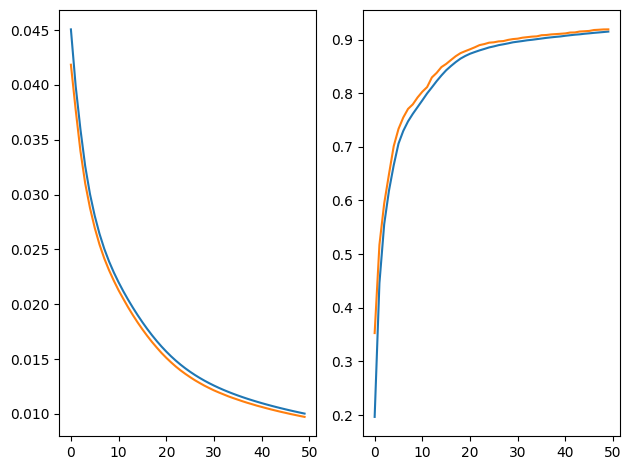

In [27]:
fig, axes = plt.subplots(ncols=2)
axes[0].plot(train_loss)
axes[0].plot(test_loss) 

axes[1].plot(train_metric)
axes[1].plot(test_metric)

plt.tight_layout()
plt.show()